# Exploratory Data Analysis

In [14]:
# importiamo i pacchetti necessari
import numpy as np 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import json

from pathlib import Path
from shapely.geometry import Point
from shapely.geometry import shape

# importazione del modulo con le funzioni
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from IPython.display import Image, display
import src.EDA_funcs as fs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# importiamo il dataframe salvato
dataframe_df = pd.read_csv('../data/processed/dataset_EDA_processed.csv')

## Studio meteo
Iniziamo dando un'occhiata ai dati sul meteo, cercando di capire se ci siano trend temporali

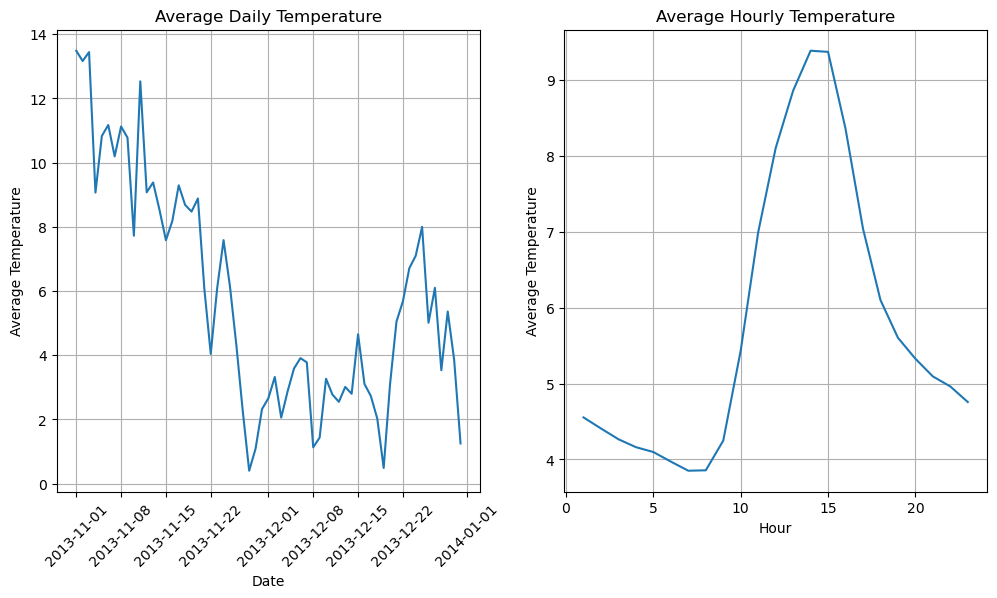

In [30]:
# Osserviamo l'andamento della temperatura in funzione dell'ora e del giorno:
hourly_temp = (dataframe_df.groupby(['hour'])['temperature'].mean().reset_index())
daily_temp = (dataframe_df.groupby(['date'])['temperature'].mean().reset_index())
daily_temp['date'] = pd.to_datetime(daily_temp['date'])

fig, axes = plt.subplots(1, 2, figsize=(12,6))

ax1 = axes[0]
ax1.plot(daily_temp['date'], daily_temp['temperature'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Temperature')
ax1.set_title('Average Daily Temperature')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True)

ax2 = axes[1]
ax2.plot(hourly_temp['hour'], hourly_temp['temperature'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average Temperature')
ax2.set_title('Average Hourly Temperature')
ax2.grid(True)

plt.show()

Chiaramente la temperatura decresce passando da Novembre a Dicembre e dimostra un chiaro trend nel corso della giornata, con un minimo alle 7 di mattina e un massimo alle due del pomeriggio. Nessuno di questi comportamenti ci sorprende.

La velocità del vento ha qualche trend?

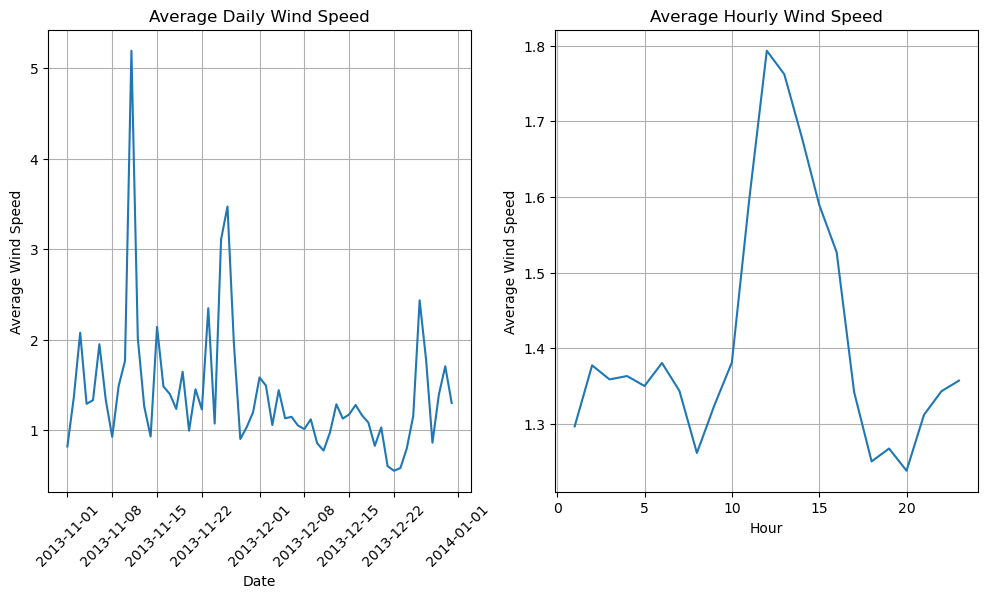

In [33]:
daily_wind = (dataframe_df.groupby(['date'])['winds_spd'].mean().reset_index())
hourly_wind = (dataframe_df.groupby(['hour'])['winds_spd'].mean().reset_index())
daily_wind['date'] = pd.to_datetime(daily_wind['date'])

fig, axes = plt.subplots(1, 2, figsize=(12,6))

ax1 = axes[0]
ax1.plot(daily_wind['date'], daily_wind['winds_spd'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Wind Speed')
ax1.set_title('Average Daily Wind Speed')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True)

ax2 = axes[1]
ax2.plot(hourly_wind['hour'], hourly_wind['winds_spd'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average Wind Speed')
ax2.set_title('Average Hourly Wind Speed')
ax2.grid(True)

plt.show()

Non osserviamo un andamento chiaro nell'andamento della velocità del vento nel periodo studiato. Tuttavia appare chiaro che la velocità del vento è maggiore tra le 10 e le 16. Questo è imputabile al Sole che splende maggiormente in quell'orario, riscaldando l'atmosfera e di conseguenza aumentando l'energia cinetica delle molecole e incrementando le turbolenze.

In [8]:
# Verifichiamo se la concentrazione dei vari inquinanti esprime una dipendenza dall'orario (probabile) o dal giorno (possibile)
pols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5']

#plt.figure(figsize=(12,30))
#
## AGGIUNGERE ANALISI SETTIMANALE
#
#i = 0
#
#for p in pols:
#    daily_p = (dataframe_df.groupby(['Data'])[p].mean().reset_index())
##   weekly_p = (dataframe_df.groupby(['Data'])[p].mean().reset_index())
#    hourly_p = (dataframe_df.groupby(['Ora'])[p].mean().reset_index())
#
#    plt.subplot(6, 3, 3*i+1)
#    plt.plot(daily_p['Data'], daily_p[p])
#    plt.xlabel('Date')
#    plt.ylabel('Average Concentration of ' + p + 'in µg/mc')
#    plt.title('Average Daily Concentration of ' + p)
#    plt.grid(True)
#
#    # qui ci andrebbe quella settimanale
#
#    plt.subplot(6, 3, 3*i+3)
#    plt.plot(hourly_wind['Ora'], hourly_p[p])
#    plt.xlabel('Hour')
#    plt.ylabel('Average Concentration of ' + p + 'in µg/mc')
#    plt.title('Average Hourly Concentration of ' + p)
#    plt.grid(True)
#    
#    i += 1
#
#del i

# NOTA: per la qualità dell'aria fare solo andamento orario e usare istogramma con 1 bin per ogni livello dell'EAQI 

#capiamo se li vogliamo effettivamente usare oppure no, sono un po' tanti grafici

Da questi grafici emergono andamenti poco chiari per le concentrazioni di inquinanti nel corso dei due mesi analizzati. D'altra parte, giornalmente le concentrazioni seguono trend che appaiono molto simili, ad eccezione dell'Ozono che appare seguire il percorso inverso. Sovrapponiamo quindi i dati per i diversi inquinanti in modo da poterli confrontare meglio 


QUANDO VIENE FATTA AGGIUNGERE DESCRIZIONE DATI SETTIMANALI

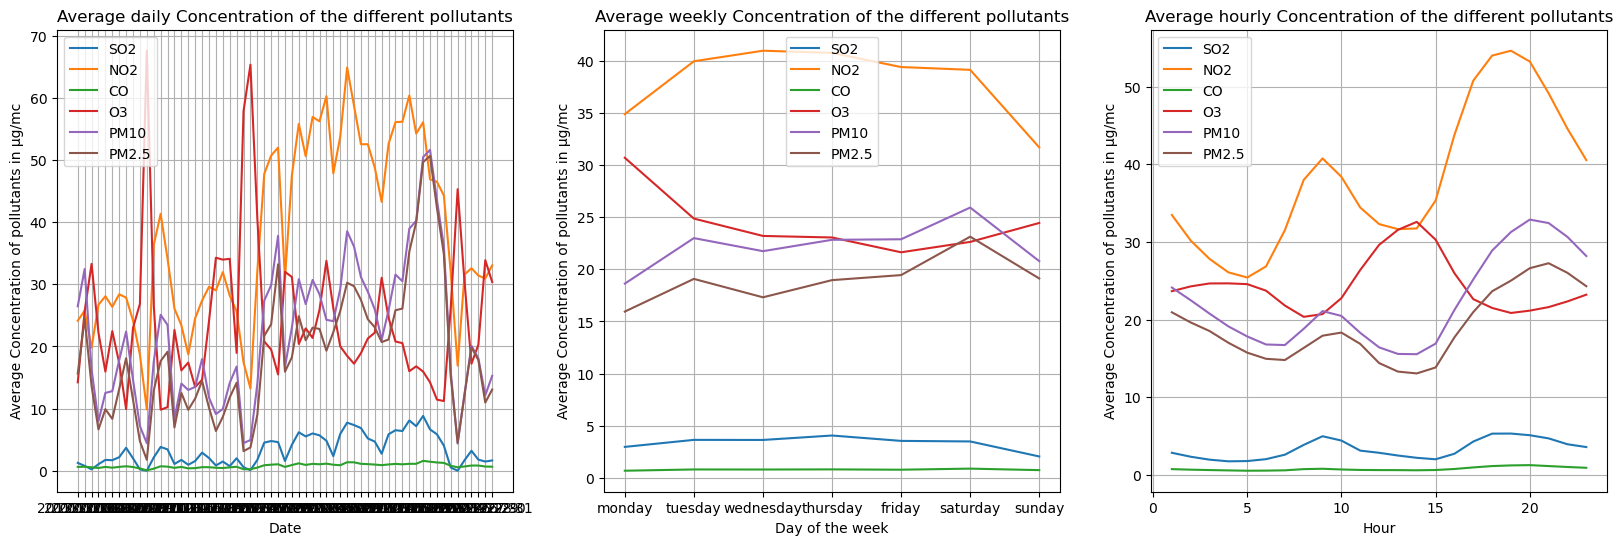

In [52]:
# Sono indeciso su questa cella, probabilente la rimuoverò

pols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax1, ax2, ax3 = axes

for p in pols:
    daily_p = (dataframe_df.groupby(['date'])[p].mean().reset_index())
    weekly_p = (dataframe_df.groupby(['week_day'])[p].mean().reset_index())
    week_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
    weekly_p['week_day'] = pd.Categorical(weekly_p['week_day'],categories=week_order,ordered=True)
    weekly_p = weekly_p.sort_values('week_day')

    hourly_p = (dataframe_df.groupby(['hour'])[p].mean().reset_index())

    ax1.plot(daily_p['date'], daily_p[p])
    ax2.plot(weekly_p['week_day'], weekly_p[p])
    ax3.plot(hourly_p['hour'], hourly_p[p])

ax1.set_xlabel('Date')
ax1.set_ylabel('Average Concentration of pollutants in µg/mc')
ax1.set_title('Average daily Concentration of the different pollutants')
ax1.legend(pols)
ax1.grid(True)

ax2.set_xlabel('Day of the week')
ax2.set_ylabel('Average Concentration of pollutants in µg/mc')
ax2.set_title('Average weekly Concentration of the different pollutants')
ax2.legend(pols)
ax2.grid(True)

ax3.set_xlabel('Hour')
ax3.set_ylabel('Average Concentration of pollutants in µg/mc')
ax3.set_title('Average hourly Concentration of the different pollutants')
ax3.legend(pols)
ax3.grid(True)

plt.show()

È difficile confrontare accuratamente il comportamento dei diversi inquinanti poiché appartengono ad ordini di grandezza differenti, in particolar modo il monossido di carbonio, quindi disegnamo di ciascuno l'andamento in scala rispetto al proprio massimo

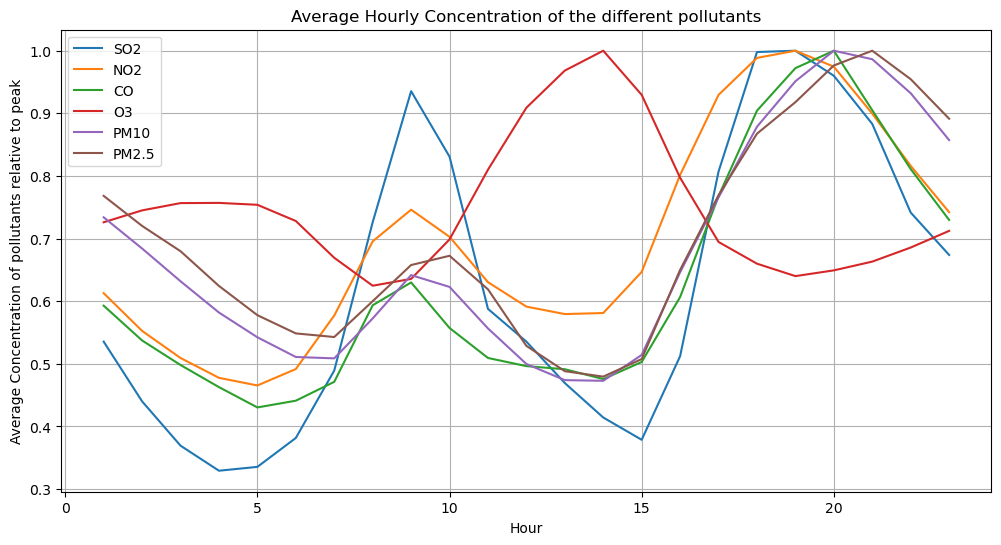

In [41]:
plt.figure(figsize=(12,6))

for p in pols:
    hourly_p = (dataframe_df.groupby(['hour'])[p].mean().reset_index())
    hourly_p[p] = hourly_p[p] / max(hourly_p[p])
    plt.plot(hourly_p['hour'], hourly_p[p])


plt.xlabel('Hour')
plt.ylabel('Average Concentration of pollutants relative to peak')
plt.title('Average Hourly Concentration of the different pollutants')
plt.legend(pols)
plt.grid(True)

Appare chiaro che, ad eccezione dell'Ozono (che segue un trend opposto) tutti gli inquinanti si comportano allo stesso modo, esibendo alte concentrazioni attorno alle 9 di mattina  e tra le 7 e le 9 di sera mentre l'aria è più pulita attorno alle 6 di mattina e alle 2 del pomeriggio. Questo comportamento così evidente è sensato poiché questi materiali inquinanti sono prodotti principalmente da attività umane e, pertanto, è sensato che seguano i ritmi quotidiani della società.

Tracciamo anche l'andamento della qualità dell'aria al variare dell'ora disegnando un istogramma.

/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_36993/4017803550.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (histogram_df.groupby(['hour', 'EAQI']).size().unstack(fill_value=0))


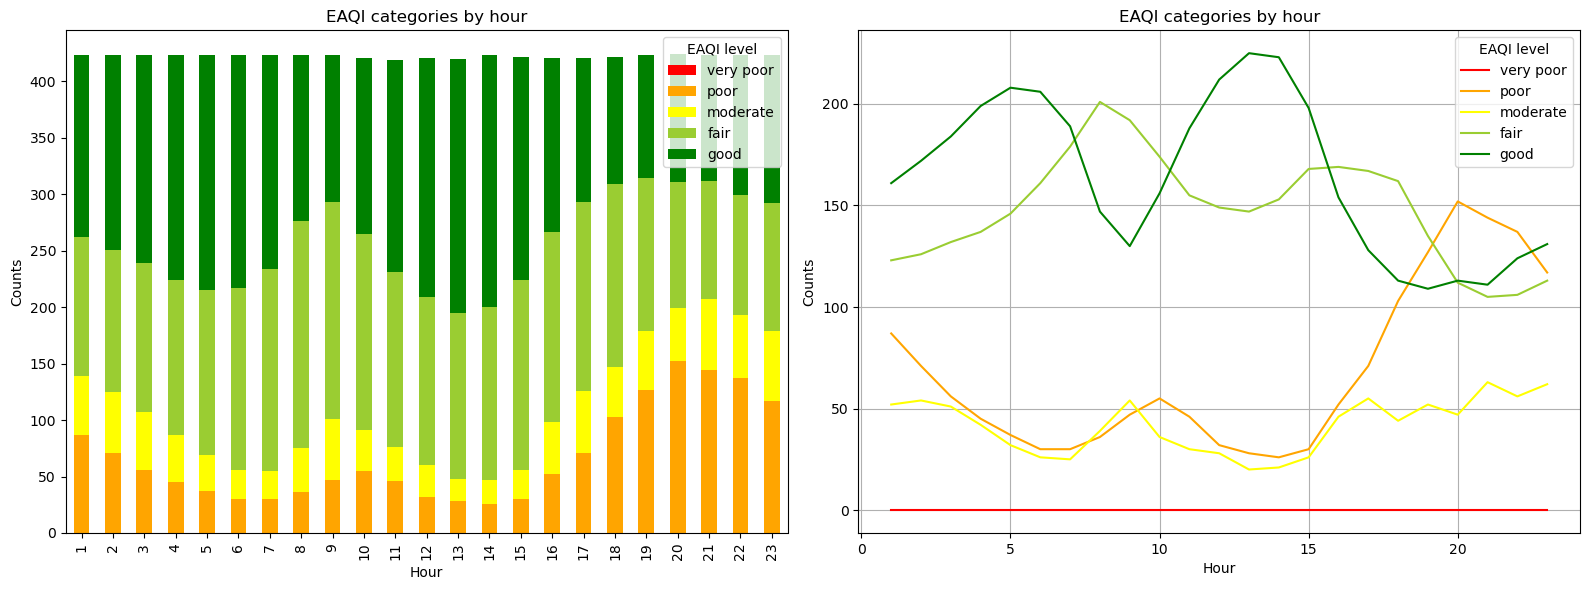

In [54]:
EAQI_ORDER = {'good': 4, 'fair': 3, 'moderate': 2, 'poor': 1, 'very poor': 0}

# non vogliamo alterare il nostro dataframe originale
histogram_df = dataframe_df.copy()

# scegliamo un ordine di colori intuitivo
category_order = ['very poor', 'poor', 'moderate', 'fair', 'good']
colors = {'good': 'green', 'fair': 'yellowgreen', 'moderate': 'yellow', 'poor': 'orange', 'very poor': 'red'}

histogram_df['EAQI'] = pd.Categorical(histogram_df['EAQI'], categories=category_order, ordered=True)

# contiamo il numero di osservazioni per ogni combinazione di ora e categoria EAQI
counts = (histogram_df.groupby(['hour', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])

counts.plot(color=[colors[c] for c in category_order], ax = axes[1])

        
#counts.plot(kind='bar', stacked=False, color=[colors[c] for c in category_order], width = 1, ax = axes[1])


axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Counts')
axes[0].set_title('EAQI categories by hour')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Counts')
axes[1].set_title('EAQI categories by hour')
axes[1].legend(title='EAQI level')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Questi grafici indicano che la qualità dell'aria è migliore attorno alle 6 e alle 14 mentre peggiora significativamente tra le 20 e le 21. Per curiosità replichiamo la procedura ma nel corso della settimana.

In [ ]:
EAQI_ORDER = {'good': 4, 'fair': 3, 'moderate': 2, 'poor': 1, 'awful': 0}

# we don't want to alter our original dataframe
histogram_df = dataframe_df.copy()

# the data must be presented in a consistent order and with intuitive color
category_order = ['awful', 'poor', 'moderate', 'fair', 'good']
colors = {'good': 'green', 'fair': 'yellowgreen', 'moderate': 'yellow', 'poor': 'orange', 'awful': 'red'}

histogram_df['EAQI'] = pd.Categorical(histogram_df['EAQI'], categories=category_order, ordered=True)

# Count occurrences for each hour and EAQI category
counts = (dataframe_df.groupby(['week_day', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])

counts.plot(color=[colors[c] for c in category_order], ax = axes[1])

        
#counts.plot(kind='bar', stacked=False, color=[colors[c] for c in category_order], width = 1, ax = axes[1])


axes[0].set_xlabel('Week Day')
axes[0].set_ylabel('Counts')
axes[0].set_title('EAQI categories by hour')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Week Day')
axes[1].set_ylabel('Counts')
axes[1].set_title('EAQI categories by hour')
axes[1].legend(title='EAQI level')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Studiamo ora le correlazioni tra le varie feature del nostro dataframe, in modo da capire quali sono collegate maggiormente.

NameError: name 'sns' is not defined

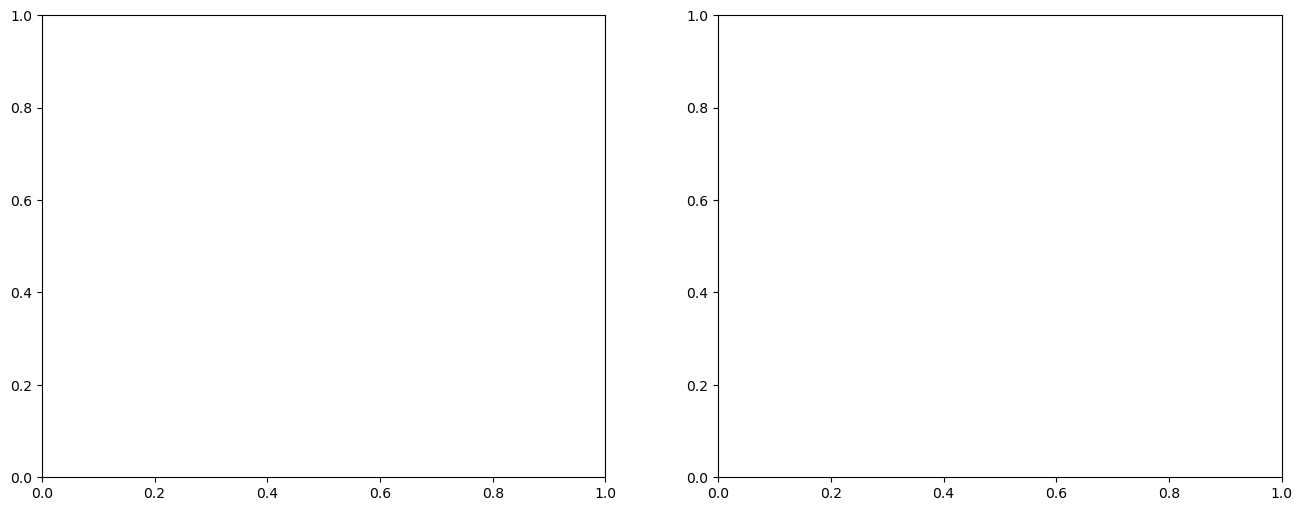

In [12]:
# c'è correlazione tra elevation - temperature - precipitation - wind - pollutants? 

corr_df = dataframe_df.copy()

# cambiamo la data in un intero che va da 0 (2013-11-01) a 60 (2013-12-31)
corr_df['date'] = corr_df['date'].apply(fs.datetime_to_int)

analyzed_features = ['date', 'week_day', 'hour', 'SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'temperature', 'precipitation', 'winds_spd', 'winds_dir']

# NOTA: QUANDO CI SARANNO AGGIUNGERE ASSOLUTAMENTE ELEVAZIONE E CONSUMI ELETTRICI

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(corr_df[analyzed_features].corr(), ax=axes[0])
plt.subplot(1, 2, 2)
sns.heatmap(corr_df[analyzed_features].corr(), annot=True, ax=axes[1])

La matrice di correlazione indica alcuni trend interessanti:
-  Le concentrazioni di quasi tutti gli inquinanti (l'ozono è l'unica eccezione) crescono con il passare dei giorni.
-  L'ora esibisce correlazioni deboli con tutte le grandezze, nonostante sia evidente dagli scorsi grafici. Questo è dovuto al fatto che la correlazione di Pearson è utile per trovare trend lineari ma poco adatta a studiare dati come quelli orari che devono per forza di cose esibire una periodicità (il valore alle 24 è l'ultimo ma anche precedente al dato dell'1).
-  Nel quadrato di dati relativi agli inquinanti, sono presenti alcuni buchi, questo è indice del fatto che non tutte le stazioni APPA registrano dati per tutti gli inquinanti. Per alcune coppie di inquinanti, infatti, non è presente una stazione che li registri entrambi e, pertanto, non è possibile stabilire una correlazione.
-  Ad eccezione dell'ozono, tutti gli inquinanti sono fortemente correlati positivamente tra loro mentre l'ozono mostra una forte anticorrelazione rispetto agli altri. Questo è perfettamente in accordo con il grafico tracciato prima.
-  Vediamo una forte anticorrelazione tra la data e la temperatura. Questo è dovuto al periodo dell'anno analizzato (fine dell'autunno e inizio dell'inverno) e la correlazione sarebbe probabilmente nulla (o leggermente positiva dato il cambiamento climatico) se considerassimo un anno intero. Lo stesso discorso vale probabilmente anche per la velocità del vento.
-  Temperatura e velocità del vento sono correlate positivamente. Questo è imputabile al maggiore movimento delle particelle calde che risulta in più turbolenze e quindi venti più intensi.
-  È chiara l'anticorrelazione tra temperatura e velocità del vento da una parte e inquinanti dall'altra. Come sopra, l'ozono si muove in controtendenza rispetto agli altri inquinanti.
-  Le precipitazioni appaiono indipendenti rispetto a tutte le altre grandezze analizzate.

AGGIUNGERE COMMENTO SU ELETTRICITÀ E ELEVAZIONE

Come accennato sopra, le precipitazioni appaiono indipendenti rispetto a tutte le altre grandezze analizzate. Questo differisce da ciò che ci suggerisce l'intuito. Infatti, ci aspetteremmo che la pioggia abbassi la temperatura e riduca la concentrazione di inquinanti nell'aria. Ipotizziamo che questa mancata correlazione possa essere dovuta al fatto che gli effetti delle precipitazioni sono avvertiti con un certo ritardo. Proviamo quindi a traslare indietro nel tempo la colonna delle precipitazioni e verificare se la correlazione aumenta, diminuisce oppure rimane invariata.

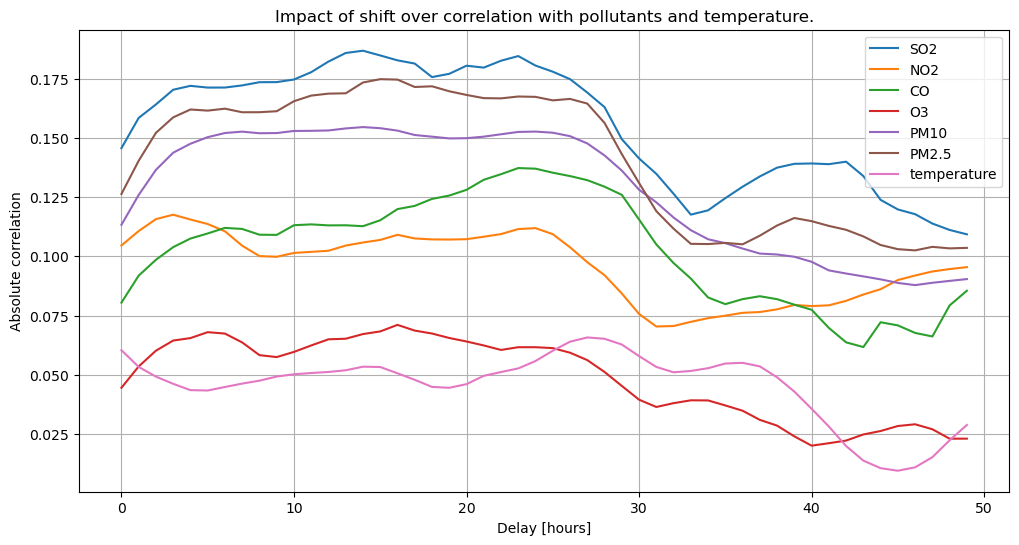

In [13]:
delay_df = dataframe_df.copy()

plt.figure(figsize=(12,6))

possible_shifts = range(0, 50)

interesting_features = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'temperature']
for p in interesting_features:
    
    shifts = {}

    for ps in possible_shifts:
        
        shifted = fs.shift_prec(delay_df, hours=ps)
        
        corr = shifted.corr(delay_df[p])
        
        shifts[ps] = abs(corr)
    
    plt.plot(shifts.keys(), shifts.values())

    
plt.xlabel("Delay [hours]")
plt.ylabel("Absolute correlation")
plt.title('Impact of shift over correlation with pollutants and temperature.')
plt.grid(True)
plt.legend(interesting_features)
plt.show()

Vediamo che, ad eccezione della temperatura, aggiungere un ritardo di poche ore rafforza significativamente la correlazione tra precipitazione ed inquinanti. Chiaramente dopo una certa soglia la correlazione si indebolisce visto il grande intervallo temporale che intercorre tra le precipitazioni e gli inquinanti. Rimane tuttavia importante sottolineare che in ogni caso le correlazioni rimangono piuttosto deboli.